# Разведочный анализ данных (EDA)

**Файл:** `yellow_tripdata_2026-01.parquet`
**Что это:** данные поездок нью-йоркского такси (NYC Yellow Taxi) за январь 2026 года.

Ноутбук пошагово отвечает на вопрос "что внутри этих данных": структура, размер, пропуски, статистики, распределения и связи между признаками.

Python 3.12.7. Зависимости: `pandas`, `pyarrow`, `matplotlib`.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

FILE_PATH = "yellow_tripdata_2026-01.parquet"  # укажите путь к файлу, если он лежит в другом месте

df = pd.read_parquet(FILE_PATH, engine="pyarrow")
df.shape

(3724889, 20)

## 1. Общий обзор: размер, колонки, типы данных

In [28]:
print(f"Строк: {df.shape[0]:,}")
print(f"Колонок: {df.shape[1]}")
print()
df.dtypes

Строк: 3,724,889
Колонок: 20



VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [29]:
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
6,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,11.4,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0.0,2.90,1.0,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.00,2.5,0.0,0.75
8,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,37.3,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
9,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3.0,1.83,1.0,N,237,263,1,10.7,1.00,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.00


## 2. Описание колонок

Стандартный словарь данных NYC TLC Yellow Taxi:

| Колонка | Описание |
|---|---|
| VendorID | Код провайдера, предоставившего запись (1 = Creative Mobile Technologies, 2 = Curb Mobility, 6 = Myle Technologies, 7 = Helix) |
| tpep_pickup_datetime | Дата и время посадки пассажира |
| tpep_dropoff_datetime | Дата и время высадки пассажира |
| passenger_count | Количество пассажиров (заполняется водителем) |
| trip_distance | Расстояние поездки в милях |
| RatecodeID | Итоговый примененный тариф (1=стандартный, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=договорной, 6=групповая поездка) |
| store_and_fwd_flag | Флаг: запись хранилась в памяти перед отправкой (нет связи с сервером) |
| PULocationID | Зона посадки (TLC Taxi Zone) |
| DOLocationID | Зона высадки (TLC Taxi Zone) |
| payment_type | Способ оплаты (1=карта, 2=наличные, 3=без оплаты, 4=спор, 5=неизвестно, 6=аннулировано) |
| fare_amount | Тариф по счетчику |
| extra | Доплаты (час пик, ночной тариф и т.п.) |
| mta_tax | Налог MTA (0.50 usd) |
| tip_amount | Чаевые (только для карт) |
| tolls_amount | Дорожные сборы |
| improvement_surcharge | Сбор на улучшение обслуживания |
| total_amount | Итоговая сумма к оплате |
| congestion_surcharge | Сбор за перегруженность (Манхэттен) |
| Airport_fee | Аэропортовый сбор |
| cbd_congestion_fee | Сбор за въезд в центральную деловую зону (CBD) |


## 3. Пропущенные значения

In [30]:
na = df.isna().sum()
na_pct = (na / len(df) * 100).round(2)
pd.DataFrame({"missing_count": na, "missing_pct": na_pct}).query("missing_count > 0").sort_values("missing_count", ascending=False)

,missing_count,missing_pct
passenger_count,1088058,29.21
RatecodeID,1088058,29.21
store_and_fwd_flag,1088058,29.21
congestion_surcharge,1088058,29.21
Airport_fee,1088058,29.21


## 4. Описательная статистика по числовым признакам

In [31]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3724889.0,1.873598,1.0,2.0,2.0,2.0,7.0,0.701458
tpep_pickup_datetime,3724889,2026-01-17 01:44:52.106518,2025-12-31 23:57:29,2026-01-09 17:51:59,2026-01-16 21:20:56,2026-01-24 07:25:11,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3724889,2026-01-17 02:02:03.696138,2025-12-31 23:57:32,2026-01-09 18:08:47,2026-01-16 21:36:14,2026-01-24 07:40:22,2026-02-01 23:35:31,NaN
passenger_count,2636831.0,1.256271,0.0,1.0,1.0,1.0,9.0,0.670243
trip_distance,3724889.0,6.455647,0.0,1.0,1.81,3.73,269097.48,648.885528
RatecodeID,2636831.0,5.218853,1.0,1.0,1.0,1.0,99.0,19.653699
PULocationID,3724889.0,161.43719,1.0,114.0,161.0,233.0,265.0,67.066574
DOLocationID,3724889.0,160.99357,1.0,107.0,162.0,234.0,265.0,71.03604
payment_type,3724889.0,0.846564,0.0,0.0,1.0,1.0,4.0,0.712049
fare_amount,3724889.0,20.804254,-2555.2,10.0,15.6,26.1,2555.2,18.927007


## 5. Категориальные / кодовые поля

In [32]:
for col in ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- VendorID ---
VendorID
2    2965742
1     710425
7      44705
6       4017
Name: count, dtype: int64

--- RatecodeID ---
RatecodeID
1.0     2390495
NaN     1088058
99.0     110864
2.0       83592
5.0       32030
3.0       11541
4.0        8304
6.0           5
Name: count, dtype: int64

--- payment_type ---
payment_type
1    2249747
0    1088058
2     314043
4      56400
3      16641
Name: count, dtype: int64

--- store_and_fwd_flag ---
store_and_fwd_flag
N       2634494
None    1088058
Y          2337
Name: count, dtype: int64



## 6. Временной диапазон и период данных

In [33]:
print("Первая посадка:", df["tpep_pickup_datetime"].min())
print("Последняя посадка:", df["tpep_pickup_datetime"].max())
print("Первая высадка:", df["tpep_dropoff_datetime"].min())
print("Последняя высадка:", df["tpep_dropoff_datetime"].max())

# Длительность поездки в минутах
trip_minutes = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
print()
print("Длительность поездки (мин) — описание:")
print(trip_minutes.describe())

Первая посадка: 2025-12-31 23:57:29
Последняя посадка: 2026-02-01 00:45:01
Первая высадка: 2025-12-31 23:57:32
Последняя высадка: 2026-02-01 23:35:31

Длительность поездки (мин) — описание:
count    3.724889e+06
mean     1.719316e+01
std      2.517802e+01
min     -1.170000e+01
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
max      7.507900e+03
dtype: float64


## 7. Распределения ключевых величин

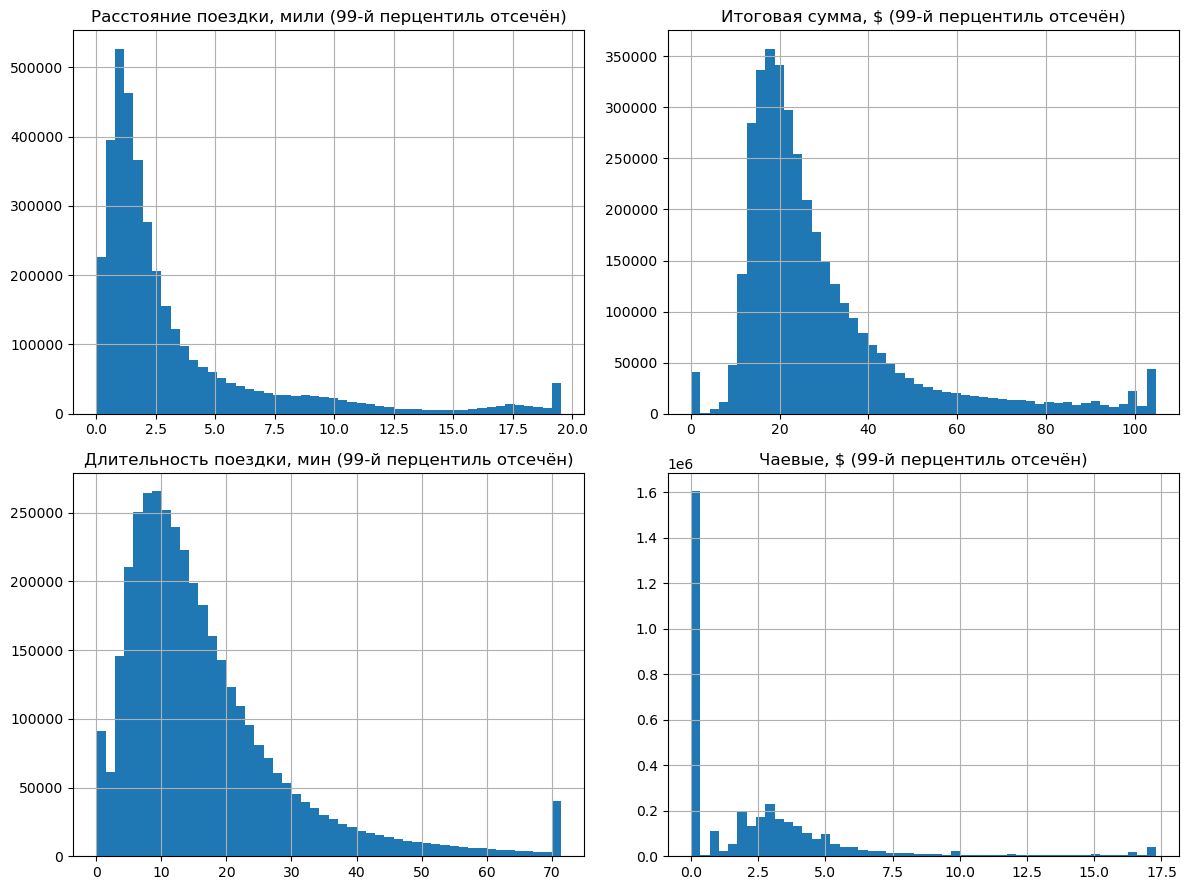

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df["trip_distance"].clip(upper=df["trip_distance"].quantile(0.99)).hist(bins=50, ax=axes[0,0])
axes[0,0].set_title("Расстояние поездки, мили (99-й перцентиль отсечен)")

df["total_amount"].clip(lower=0, upper=df["total_amount"].quantile(0.99)).hist(bins=50, ax=axes[0,1])
axes[0,1].set_title("Итоговая сумма, $ (99-й перцентиль отсечен)")

trip_minutes.clip(lower=0, upper=trip_minutes.quantile(0.99)).hist(bins=50, ax=axes[1,0])
axes[1,0].set_title("Длительность поездки, мин (99-й перцентиль отсечен)")

df["tip_amount"].clip(lower=0, upper=df["tip_amount"].quantile(0.99)).hist(bins=50, ax=axes[1,1])
axes[1,1].set_title("Чаевые, $ (99-й перцентиль отсечен)")

plt.tight_layout()
plt.show()

## 8. Динамика поездок по времени

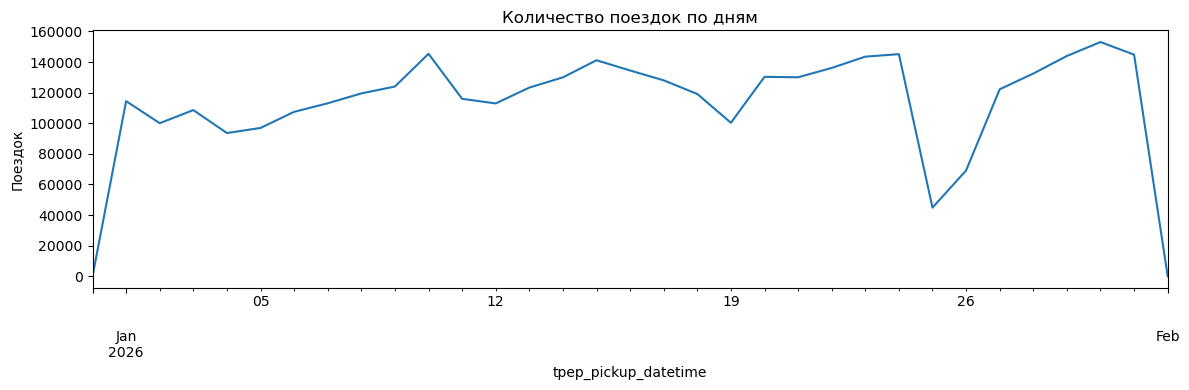

In [35]:
by_day = df.set_index("tpep_pickup_datetime").resample("D").size()

fig, ax = plt.subplots(figsize=(12, 4))
by_day.plot(ax=ax)
ax.set_title("Количество поездок по дням")
ax.set_ylabel("Поездок")
plt.tight_layout()
plt.show()

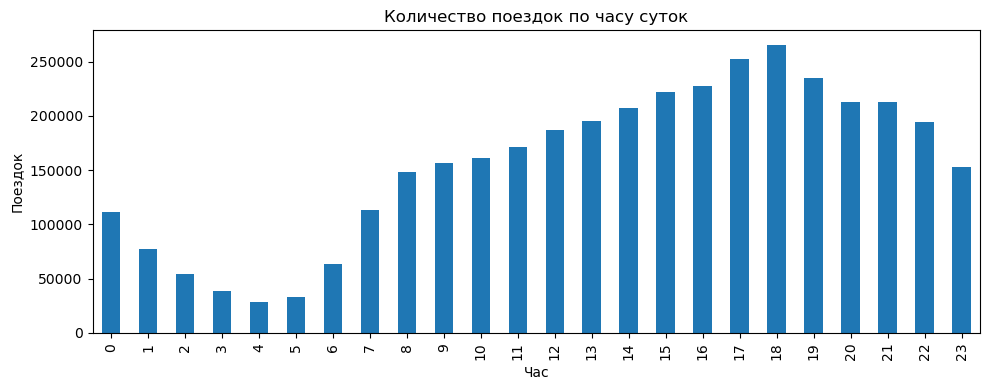

In [36]:
by_hour = df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
by_hour.plot(kind="bar", ax=ax)
ax.set_title("Количество поездок по часу суток")
ax.set_xlabel("Час")
ax.set_ylabel("Поездок")
plt.tight_layout()
plt.show()

## 9. Способ оплаты и чаевые

In [37]:
payment_labels = {1: "Карта", 2: "Наличные", 3: "Без оплаты", 4: "Спор", 5: "Неизвестно", 6: "Отменено"}
payment_share = df["payment_type"].map(payment_labels).value_counts(normalize=True).mul(100).round(2)
payment_share

payment_type
Карта         85.32
Наличные      11.91
Спор           2.14
Без оплаты     0.63
Name: proportion, dtype: float64

In [38]:
tip_pct = (df["tip_amount"] / df["fare_amount"].replace(0, pd.NA) * 100)
print("Средний % чаевых (только карта, где fare > 0):")
print(tip_pct[df["payment_type"] == 1].describe())

Средний % чаевых (только карта, где fare > 0):
count     2249724.0
unique      41782.0
top             0.0
freq       211256.0
dtype: float64


## 10. Аномалии и выбросы

In [39]:
anomalies = {
    "trip_distance == 0": (df["trip_distance"] == 0).sum(),
    "trip_distance > 100 миль": (df["trip_distance"] > 100).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
    "fare_amount < 0": (df["fare_amount"] < 0).sum(),
    "passenger_count == 0": (df["passenger_count"] == 0).sum(),
    "длительность <= 0 мин": (trip_minutes <= 0).sum(),
    "длительность > 3 часов": (trip_minutes > 180).sum(),
}
pd.Series(anomalies, name="count")

trip_distance == 0          125738
trip_distance > 100 миль       162
total_amount <= 0            40417
fare_amount < 0              39463
passenger_count == 0         14787
длительность <= 0 мин        45070
длительность > 3 часов        1755
Name: count, dtype: int64

## 11. Топ зон посадки/высадки

In [40]:
print("Топ-10 зон посадки (PULocationID):")
print(df["PULocationID"].value_counts().head(10))
print()
print("Топ-10 зон высадки (DOLocationID):")
print(df["DOLocationID"].value_counts().head(10))

Топ-10 зон посадки (PULocationID):
PULocationID
237    160343
236    153640
132    152589
161    146641
186    110700
142    110004
162    108703
230    106114
79     100998
239     97465
Name: count, dtype: int64

Топ-10 зон высадки (DOLocationID):
DOLocationID
236    156661
237    146726
161    121571
170     99583
230     99157
142     97680
239     97287
141     95943
68      90437
162     89412
Name: count, dtype: int64


## 12. Корреляции между числовыми признаками

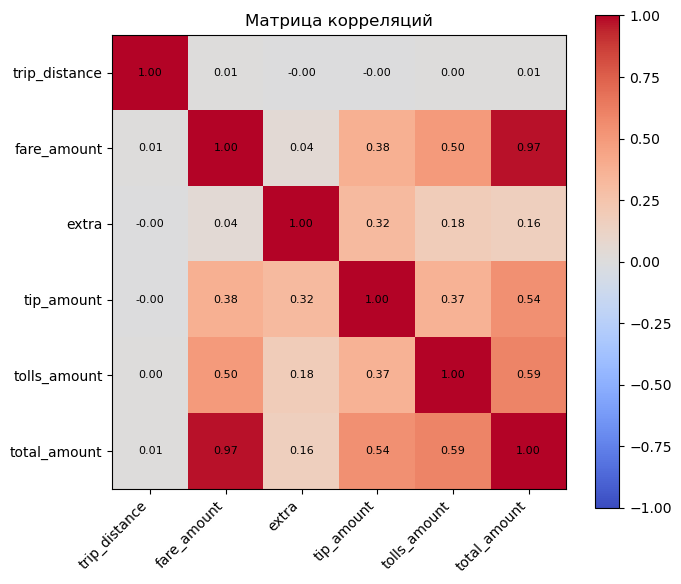

In [41]:
num_cols = ["trip_distance", "fare_amount", "extra", "tip_amount", "tolls_amount", "total_amount"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Матрица корреляций")
plt.tight_layout()
plt.show()

## 13. Итоги

Кратко резюмируйте здесь основные наблюдения после запуска ноутбука на своих данных: объем, охваченный период, качество данных (пропуски/аномалии), основные закономерности по времени суток и способу оплаты.

## 14. Геокарта зон такси (NYC Taxi Zones)

NYC TLC делит город на 263 географические зоны (`LocationID`), которые используются в колонках `PULocationID` (посадка) и `DOLocationID` (высадка). Ниже — границы зон в виде geopandas `GeoDataFrame` и хороплет-карта числа поездок по зоне.

Требуются пакеты `geopandas`, `shapely`, `pyproj`, `plotly`. Файлы шейпфайла (`taxi_zones.shp` и сопутствующие) должны лежать в подпапке `taxi_zones/` рядом с этим ноутбуком.

In [42]:
import geopandas as gpd

zones = gpd.read_file("taxi_zones/taxi_zones.shp").to_crs(epsg=4326)
zones["LocationID"] = zones["LocationID"].astype(int)
print(zones.shape)
zones.head(3)

(263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."


In [43]:
#!pip install geopandas

Границы всех 263 зон, окрашенные по округу (borough):

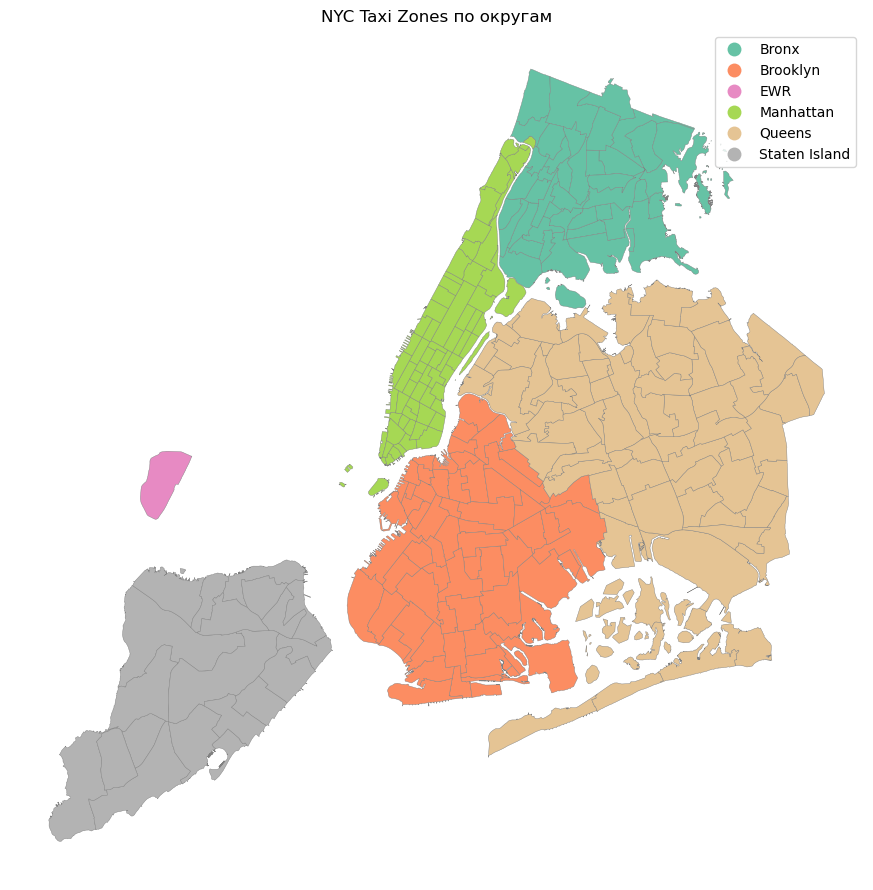

In [44]:
fig, ax = plt.subplots(figsize=(9, 9))
zones.plot(column="borough", categorical=True, legend=True, linewidth=0.3, edgecolor="grey", ax=ax, cmap="Set2")
ax.set_title("NYC Taxi Zones по округам")
ax.axis("off")
plt.tight_layout()
plt.show()

Хороплет-карта: число посадок по зоне за январь 2026.

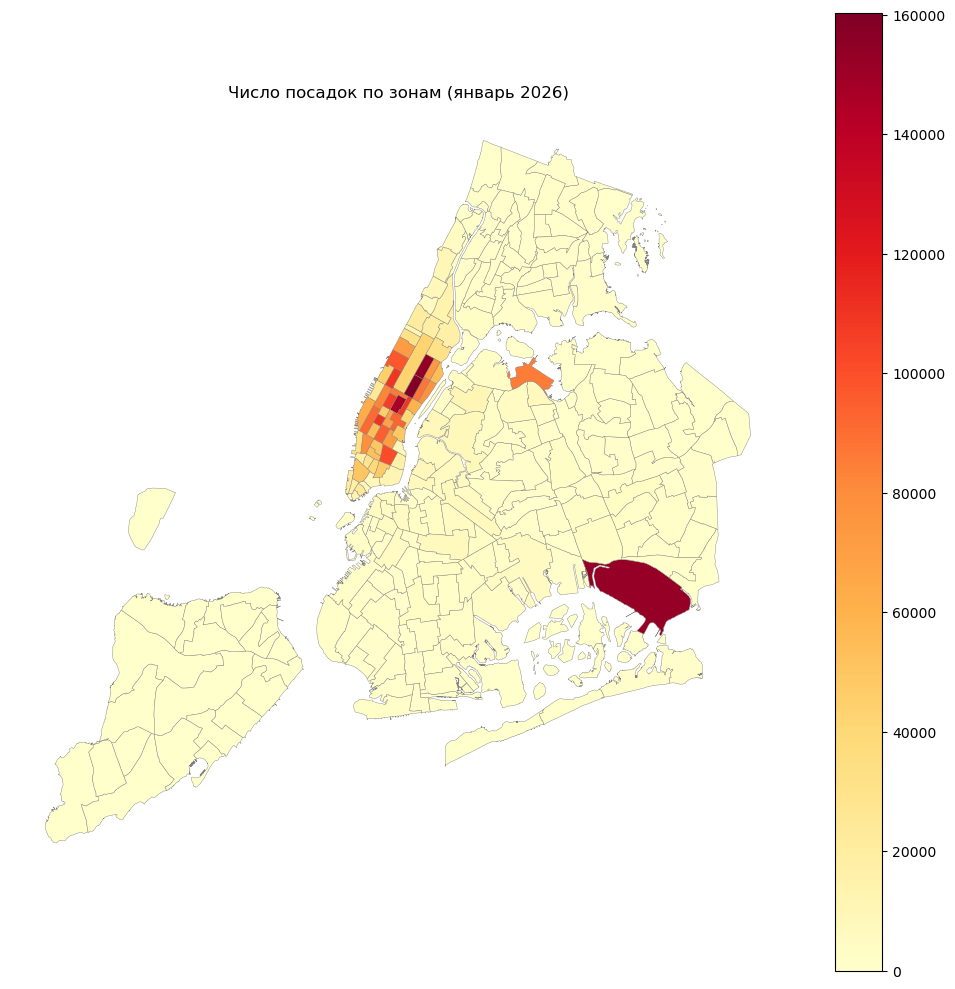

,LocationID,zone,borough,pickups
236,237,Upper East Side South,Manhattan,160343.0
235,236,Upper East Side North,Manhattan,153640.0
131,132,JFK Airport,Queens,152589.0
160,161,Midtown Center,Manhattan,146641.0
185,186,Penn Station/Madison Sq West,Manhattan,110700.0
141,142,Lincoln Square East,Manhattan,110004.0
161,162,Midtown East,Manhattan,108703.0
229,230,Times Sq/Theatre District,Manhattan,106114.0
78,79,East Village,Manhattan,100998.0
238,239,Upper West Side South,Manhattan,97465.0


In [45]:
pu_counts = df["PULocationID"].value_counts().rename("pickups").reset_index()
pu_counts.columns = ["LocationID", "pickups"]

zones_pu = zones.merge(pu_counts, on="LocationID", how="left")
zones_pu["pickups"] = zones_pu["pickups"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
zones_pu.plot(column="pickups", cmap="YlOrRd", linewidth=0.3, edgecolor="grey", legend=True, ax=ax)
ax.set_title("Число посадок по зонам (январь 2026)")
ax.axis("off")
plt.tight_layout()
plt.show()

zones_pu[["LocationID", "zone", "borough", "pickups"]].sort_values("pickups", ascending=False).head(10)

То же самое для высадок (`DOLocationID`), для сравнения.

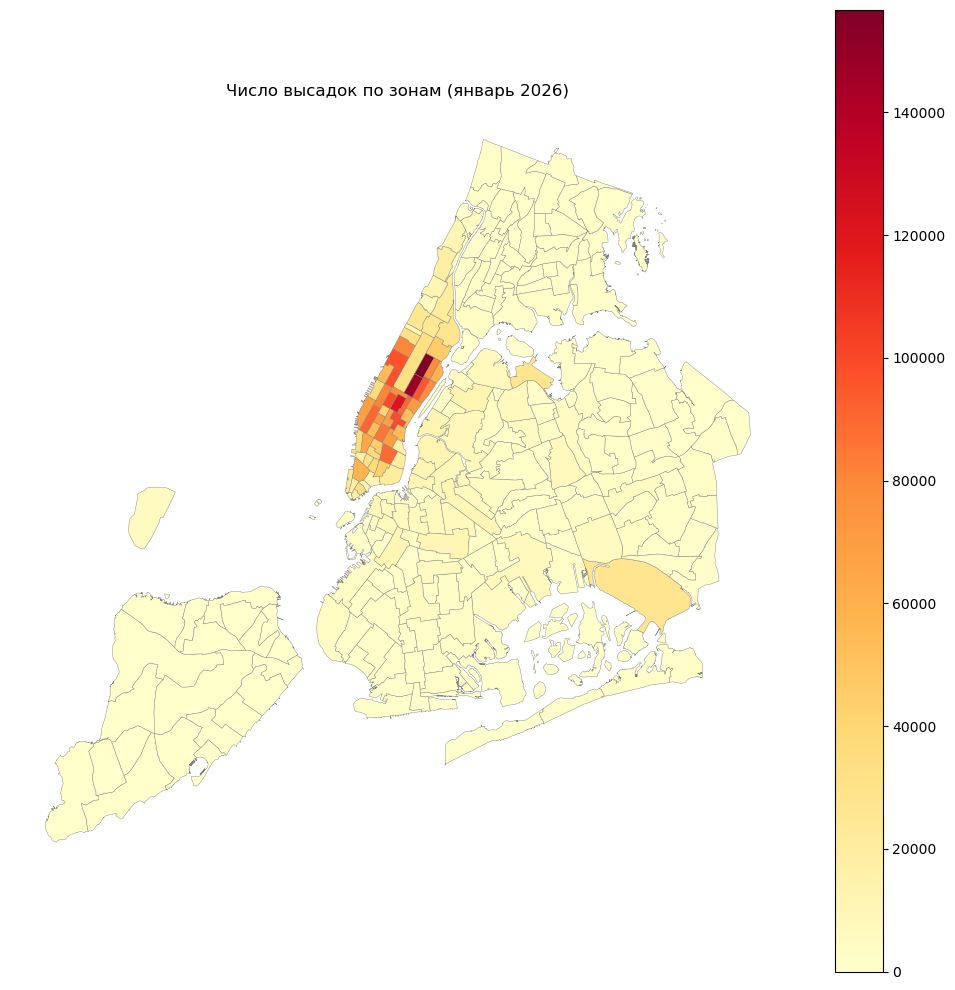

In [46]:
do_counts = df["DOLocationID"].value_counts().rename("dropoffs").reset_index()
do_counts.columns = ["LocationID", "dropoffs"]

zones_do = zones.merge(do_counts, on="LocationID", how="left")
zones_do["dropoffs"] = zones_do["dropoffs"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
zones_do.plot(column="dropoffs", cmap="YlOrRd", linewidth=0.3, edgecolor="grey", legend=True, ax=ax)
ax.set_title("Число высадок по зонам (январь 2026)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Интерактивная карта

Ниже строится интерактивная карта (Plotly, слой carto-positron) и сохраняется в отдельный HTML-файл рядом с ноутбуком — так она не раздувает сам `.ipynb`. Откройте `nyc_taxi_zones_map.html` в браузере, чтобы приближать/наводить курсор на зоны.

In [47]:
import json
import plotly.express as px

zones_pu_str = zones_pu.copy()
zones_pu_str["LocationID"] = zones_pu_str["LocationID"].astype(str)
geojson_data = json.loads(zones_pu_str.to_json())

fig = px.choropleth_map(
    zones_pu_str,
    geojson=geojson_data,
    locations="LocationID",
    featureidkey="properties.LocationID",
    color="pickups",
    color_continuous_scale="YlOrRd",
    hover_data=["zone", "borough", "pickups"],
    map_style="carto-positron",
    zoom=9.3,
    center={"lat": 40.72, "lon": -73.95},
    opacity=0.75,
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0), title="Поездки такси по зонам посадки (январь 2026)")
fig.write_html("nyc_taxi_zones_map.html")
print("Сохранено: nyc_taxi_zones_map.html")

Сохранено: nyc_taxi_zones_map.html


## 15. Поток клиентов такси: откуда и куда

Предыдущие карты показывали посадки и высадки по отдельности. Здесь — сама **связь** между зонами: сколько поездок идет по каждому маршруту "зона посадки → зона высадки", в каком направлении течет основной поток между округами (boroughs), и как это выглядит на карте.

In [48]:
same_zone = (df["PULocationID"] == df["DOLocationID"]).sum()
print(f"Поездок внутри одной зоны (PU == DO): {same_zone:,} ({same_zone / len(df) * 100:.1f}%)")

# Пары "откуда -> куда" между разными зонами
od_pairs = df.groupby(["PULocationID", "DOLocationID"]).size().reset_index(name="trips")
od_pairs = od_pairs[od_pairs["PULocationID"] != od_pairs["DOLocationID"]]
print(f"Уникальных маршрутов между разными зонами: {len(od_pairs):,}")

Поездок внутри одной зоны (PU == DO): 177,441 (4.8%)
Уникальных маршрутов между разными зонами: 40,051


In [49]:
zone_names = zones.set_index("LocationID")[["zone", "borough"]]

top_routes = od_pairs.sort_values("trips", ascending=False).head(15).copy()
top_routes["from"] = top_routes["PULocationID"].map(zone_names["zone"])
top_routes["from_borough"] = top_routes["PULocationID"].map(zone_names["borough"])
top_routes["to"] = top_routes["DOLocationID"].map(zone_names["zone"])
top_routes["to_borough"] = top_routes["DOLocationID"].map(zone_names["borough"])

print("Топ-15 маршрутов между зонами по числу поездок:")
top_routes[["from", "from_borough", "to", "to_borough", "trips"]].reset_index(drop=True)

Топ-15 маршрутов между зонами по числу поездок:


,from,from_borough,to,to_borough,trips
0,Upper East Side South,Manhattan,Upper East Side North,Manhattan,24197
1,Upper East Side North,Manhattan,Upper East Side South,Manhattan,21055
2,Midtown Center,Manhattan,Upper East Side South,Manhattan,10380
3,Upper East Side South,Manhattan,Midtown Center,Manhattan,9541
4,Lincoln Square East,Manhattan,Upper West Side South,Manhattan,9065
5,Upper West Side South,Manhattan,Upper West Side North,Manhattan,8919
6,Upper West Side South,Manhattan,Lincoln Square East,Manhattan,8622
7,Midtown Center,Manhattan,Upper East Side North,Manhattan,8573
8,Lenox Hill West,Manhattan,Upper East Side North,Manhattan,8565
9,Upper East Side North,Manhattan,Lenox Hill West,Manhattan,8211


### Поток между округами (Sankey-диаграмма)

263 зоны — слишком мелкая детализация, чтобы увидеть общую картину потока. Агрегируем до уровня округа (`borough`): слева — округ посадки, справа — округ высадки, толщина ленты — число поездок.

In [50]:
import plotly.graph_objects as go

borough_of = zones.set_index("LocationID")["borough"]
od_borough = pd.DataFrame({
    "from_borough": df["PULocationID"].map(borough_of),
    "to_borough": df["DOLocationID"].map(borough_of),
})
borough_flow = od_borough.groupby(["from_borough", "to_borough"]).size().reset_index(name="trips")

# Фиксированный категориальный порядок и цвета (dataviz-палитра)
categorical_order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR", "Unknown"]
categorical_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
boroughs_present = [b for b in categorical_order if b in borough_flow["from_borough"].unique() or b in borough_flow["to_borough"].unique()]
color_map = dict(zip(categorical_order, categorical_colors))

def hex_to_rgba(hex_color, alpha=0.4):
    hex_color = hex_color.lstrip("#")
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

node_labels = [f"{b} (откуда)" for b in boroughs_present] + [f"{b} (куда)" for b in boroughs_present]
src_idx = {b: i for i, b in enumerate(boroughs_present)}
dst_idx = {b: i + len(boroughs_present) for i, b in enumerate(boroughs_present)}

sankey_df = borough_flow[
    borough_flow["from_borough"].isin(boroughs_present) & borough_flow["to_borough"].isin(boroughs_present)
]

fig = go.Figure(go.Sankey(
    node=dict(
        label=node_labels,
        color=[color_map[b] for b in boroughs_present] * 2,
        pad=20,
        thickness=18,
        line=dict(color="rgba(0,0,0,0.2)", width=0.5),
    ),
    link=dict(
        source=sankey_df["from_borough"].map(src_idx),
        target=sankey_df["to_borough"].map(dst_idx),
        value=sankey_df["trips"],
        color=sankey_df["from_borough"].map(color_map).map(lambda c: hex_to_rgba(c, 0.4)),
    ),
))
fig.update_layout(title="Поток поездок между округами (январь 2026)", font_size=12, height=500)
fig.show()

### Карта потока: топ-маршруты между зонами

Линии соединяют центроиды зоны посадки и зоны высадки для самых загруженных маршрутов; толщина и цвет линии — объем поездок (квартили по числу поездок в топ-выборке). Направление "откуда → куда" уже зафиксировано в таблице маршрутов выше и на Sankey-диаграмме. Карта сохраняется в отдельный HTML, чтобы не раздувать ноутбук.

In [51]:
# Точные центроиды: считаем в проекции NY State Plane (футы), затем возвращаем в WGS84
zones_proj = zones.to_crs(epsg=2263)
centroids_geo = gpd.GeoSeries(zones_proj.geometry.centroid, crs=2263).to_crs(epsg=4326)
zones["lon"] = centroids_geo.x
zones["lat"] = centroids_geo.y
centroids = zones.set_index("LocationID")[["lon", "lat"]]

TOP_N = 100
flows = od_pairs.sort_values("trips", ascending=False).head(TOP_N).copy()
flows = flows.join(centroids.rename(columns={"lon": "lon_from", "lat": "lat_from"}), on="PULocationID")
flows = flows.join(centroids.rename(columns={"lon": "lon_to", "lat": "lat_to"}), on="DOLocationID")

# Квартили по объему на основе уникального ранга (без проблем с повторяющимися границами)
flows["width_bin"] = pd.qcut(flows["trips"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

blue_ramp = {1: "#9ec5f4", 2: "#5598e7", 3: "#256abf", 4: "#0d366b"}  # шаги 200/350/500/700 sequential blue

fig = go.Figure()
for width_bin in sorted(flows["width_bin"].unique()):
    subset = flows[flows["width_bin"] == width_bin]
    lons, lats = [], []
    for _, row in subset.iterrows():
        lons += [row["lon_from"], row["lon_to"], None]
        lats += [row["lat_from"], row["lat_to"], None]
    fig.add_trace(go.Scattermap(
        lon=lons, lat=lats, mode="lines",
        line=dict(width=width_bin * 1.5, color=blue_ramp[width_bin]),
        opacity=0.65,
        name=f"группа {width_bin} (по объему)",
        hoverinfo="skip",
    ))

fig.add_trace(go.Scattermap(
    lon=zones["lon"], lat=zones["lat"], mode="markers",
    marker=dict(size=4, color="#0b0b0b"),
    text=zones["zone"], hoverinfo="text", name="Зоны",
))

fig.update_layout(
    map=dict(style="carto-positron", zoom=9.3, center=dict(lat=40.72, lon=-73.95)),
    margin=dict(l=0, r=0, t=40, b=0),
    title=f"Топ-{TOP_N} маршрутов такси между зонами (январь 2026)",
    showlegend=True,
)
fig.write_html("nyc_taxi_flow_map.html")
print("Сохранено: nyc_taxi_flow_map.html")

Сохранено: nyc_taxi_flow_map.html
